In [ ]:
import os
import zipfile
import shutil
from google.colab import files

# Xóa dữ liệu cũ nếu chạy lại nhiều lần để tránh xung đột
if os.path.exists('/content/dataset_raw'):
    shutil.rmtree('/content/dataset_raw')
if os.path.exists('/content/yolo_dataset'):
    shutil.rmtree('/content/yolo_dataset')
if os.path.exists('/content/runs'):
    shutil.rmtree('/content/runs')

print("📌 Vui lòng chọn file .zip chứa dataset từ máy tính của bạn...")
uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
extract_path = '/content/dataset_raw'

print(f"⏳ Đang giải nén file {zip_filename}...")
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.remove(zip_filename) # Xóa file zip để nhẹ RAM
print("✅ Giải nén hoàn tất! Dataset thô ở thư mục /content/dataset_raw")

📌 Vui lòng chọn file .zip chứa dataset từ máy tính của bạn...


Saving Test.zip to Test.zip
⏳ Đang giải nén file Test.zip...
✅ Giải nén hoàn tất! Dataset thô ở thư mục /content/dataset_raw


In [ ]:
import random
import os
import shutil

source_dir = '/content/dataset_raw/Test'
# Nếu giải nén bị lồng thêm 1 thư mục (vd: dataset_raw/dataset/), hãy chỉnh lại source_dir
# Ví dụ: source_dir = '/content/dataset_raw/dataset'

output_dir = '/content/yolo_dataset'
train_ratio = 0.8

train_path = os.path.join(output_dir, 'train')
val_path = os.path.join(output_dir, 'val')
os.makedirs(output_dir, exist_ok=True)

classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

print("--- PHÂN BỔ DỮ LIỆU TỪNG MÓN (80/20) ---")
for class_name in classes:
    os.makedirs(os.path.join(train_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_path, class_name), exist_ok=True)

    class_dir = os.path.join(source_dir, class_name)
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(images)

    split_idx = int(len(images) * train_ratio)
    train_images = images[:split_idx]
    val_images = images[split_idx:]

    for img in train_images:
        shutil.copy(os.path.join(class_dir, img), os.path.join(train_path, class_name, img))
    for img in val_images:
        shutil.copy(os.path.join(class_dir, img), os.path.join(val_path, class_name, img))

    print(f"- {class_name:<15}: {len(train_images)} train | {len(val_images)} val | Tổng: {len(images)}")

print("\n✅ Hoàn tất chia dataset chuẩn YOLO!")

--- PHÂN BỔ DỮ LIỆU TỪNG MÓN (80/20) ---
- Bun rieu       : 184 train | 47 val | Tổng: 231
- Bun mam        : 124 train | 31 val | Tổng: 155
- Banh mi        : 214 train | 54 val | Tổng: 268
- Ca kho to      : 108 train | 28 val | Tổng: 136
- Banh trang nuong: 127 train | 32 val | Tổng: 159
- Banh khot      : 133 train | 34 val | Tổng: 167
- Com tam        : 151 train | 38 val | Tổng: 189
- Chao long      : 172 train | 43 val | Tổng: 215
- Banh chung     : 81 train | 21 val | Tổng: 102
- Banh cuon      : 182 train | 46 val | Tổng: 228
- Bun dau mam tom: 147 train | 37 val | Tổng: 184
- Xoi xeo        : 84 train | 21 val | Tổng: 105
- Banh gio       : 103 train | 26 val | Tổng: 129
- Bun bo Hue     : 244 train | 62 val | Tổng: 306
- Banh pia       : 71 train | 18 val | Tổng: 89
- Banh can       : 119 train | 30 val | Tổng: 149
- Pho            : 129 train | 33 val | Tổng: 162
- Hu tieu        : 157 train | 40 val | Tổng: 197
- Canh chua      : 132 train | 33 val | Tổng: 165
- Banh xeo  

In [ ]:
import os

print(os.listdir('/content/dataset_raw'))
print(os.listdir('/content/dataset_raw/Test')) # Assuming 'vietnam_food' is the common name based on the zip file

['Test']
['Bun rieu', 'Bun mam', 'Banh mi', 'Ca kho to', 'Banh trang nuong', 'Banh khot', 'Com tam', 'Chao long', 'Banh chung', 'Banh cuon', 'Bun dau mam tom', 'Xoi xeo', 'Banh gio', 'Bun bo Hue', 'Banh pia', 'Banh can', 'Pho', 'Hu tieu', 'Canh chua', 'Banh xeo', 'Banh canh', 'Banh duc', 'Bun thit nuong', 'Nem chua', 'Cao lau', 'Banh beo', 'Banh bot loc', 'Mi quang', 'Goi cuon', 'Banh tet']


In [ ]:
import os
import shutil

print("🧹 ĐANG DỌN DẸP RÁC HỆ THỐNG...\n")

dirs_to_clean = ['/content/yolo_dataset/train', '/content/yolo_dataset/val']

for d in dirs_to_clean:
    if os.path.exists(d):
        print(f"Kiểm tra thư mục: {d}")
        for item in os.listdir(d):
            item_path = os.path.join(d, item)

            # Xóa các thư mục/file rác bắt đầu bằng dấu chấm (ẩn)
            if item.startswith('.'):
                if os.path.isdir(item_path):
                    shutil.rmtree(item_path)
                    print(f"  -> Đã tiêu diệt thư mục rác: {item}")
                else:
                    os.remove(item_path)
                    print(f"  -> Đã xóa file rác: {item}")

# Đếm và in lại danh sách class chuẩn
train_classes = sorted([d for d in os.listdir('/content/yolo_dataset/train') if os.path.isdir(os.path.join('/content/yolo_dataset/train', d))])

print("\n" + "="*40)
print(f"✅ Số lượng class hiện tại: {len(train_classes)} (Chuẩn!)")
print(f"Danh sách các món: {train_classes}")
print("="*40)

🧹 ĐANG DỌN DẸP RÁC HỆ THỐNG...

Kiểm tra thư mục: /content/yolo_dataset/train
Kiểm tra thư mục: /content/yolo_dataset/val

✅ Số lượng class hiện tại: 30 (Chuẩn!)
Danh sách các món: ['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio', 'Banh khot', 'Banh mi', 'Banh pia', 'Banh tet', 'Banh trang nuong', 'Banh xeo', 'Bun bo Hue', 'Bun dau mam tom', 'Bun mam', 'Bun rieu', 'Bun thit nuong', 'Ca kho to', 'Canh chua', 'Cao lau', 'Chao long', 'Com tam', 'Goi cuon', 'Hu tieu', 'Mi quang', 'Nem chua', 'Pho', 'Xoi xeo']


In [ ]:
import os
import shutil

print("🧹 Đang dọn dẹp class thừa 'vietnam_food'...\n")

# Danh sách các đường dẫn chứa thư mục rác cần xóa
paths_to_remove = [
    '/content/yolo_dataset/train/vietnam_food',
    '/content/yolo_dataset/val/vietnam_food',
    '/content/dataset_raw/vietnam_food' # Xóa luôn ở thư mục gốc nếu có
]

for path in paths_to_remove:
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f"💥 Đã xóa thành công: {path}")

# Kiểm tra lại lần cuối
train_classes = sorted([d for d in os.listdir('/content/yolo_dataset/train') if os.path.isdir(os.path.join('/content/yolo_dataset/train', d))])

print("\n" + "="*40)
print(f"✅ Số lượng class hiện tại: {len(train_classes)}")
print("="*40)

🧹 Đang dọn dẹp class thừa 'vietnam_food'...


✅ Số lượng class hiện tại: 30


In [ ]:
import os

train_dir = '/content/yolo_dataset/train'
val_dir = '/content/yolo_dataset/val'

print("=== KIỂM TRA SỐ LƯỢNG ẢNH TỪNG CLASS ===")
print("-----------------------------------------")

def count_images_in_dir(directory):
    class_counts = {}
    if os.path.exists(directory):
        for class_name in os.listdir(directory):
            class_path = os.path.join(directory, class_name)
            if os.path.isdir(class_path):
                image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
                class_counts[class_name] = len(image_files)
    return class_counts

train_counts = count_images_in_dir(train_dir)
val_counts = count_images_in_dir(val_dir)

all_classes = sorted(list(set(list(train_counts.keys()) + list(val_counts.keys()))))

print(f"Thư mục huấn luyện: {train_dir}")
for class_name in all_classes:
    train_num = train_counts.get(class_name, 0)
    val_num = val_counts.get(class_name, 0)
    total_num = train_num + val_num
    print(f"- {class_name:<15}: {train_num} train | {val_num} val | Tổng: {total_num}")

print("-----------------------------------------")
print("✅ Hoàn tất kiểm tra số lượng ảnh.")

=== KIỂM TRA SỐ LƯỢNG ẢNH TỪNG CLASS ===
-----------------------------------------
Thư mục huấn luyện: /content/yolo_dataset/train
- Banh beo       : 364 train | 91 val | Tổng: 455
- Banh bot loc   : 188 train | 47 val | Tổng: 235
- Banh can       : 119 train | 30 val | Tổng: 149
- Banh canh      : 154 train | 39 val | Tổng: 193
- Banh chung     : 81 train | 21 val | Tổng: 102
- Banh cuon      : 182 train | 46 val | Tổng: 228
- Banh duc       : 106 train | 27 val | Tổng: 133
- Banh gio       : 103 train | 26 val | Tổng: 129
- Banh khot      : 133 train | 34 val | Tổng: 167
- Banh mi        : 214 train | 54 val | Tổng: 268
- Banh pia       : 71 train | 18 val | Tổng: 89
- Banh tet       : 110 train | 28 val | Tổng: 138
- Banh trang nuong: 127 train | 32 val | Tổng: 159
- Banh xeo       : 188 train | 47 val | Tổng: 235
- Bun bo Hue     : 244 train | 62 val | Tổng: 306
- Bun dau mam tom: 147 train | 37 val | Tổng: 184
- Bun mam        : 124 train | 31 val | Tổng: 155
- Bun rieu       : 18

In [ ]:
# Cài đặt thư viện
!pip install ultralytics
import ultralytics
ultralytics.checks() # Đảm bảo Colab đang dùng GPU

from ultralytics import YOLO

# Khởi tạo mô hình phân loại (Bản nano nhẹ nhất)
model = YOLO('yolov8n-cls.pt')

print("🚀 Bắt đầu huấn luyện...")
# Quá trình train sẽ tự động lưu kết quả vào thư mục /content/runs/classify/train/
results = model.train(
    data='/content/yolo_dataset',
    epochs=40,       # Số vòng lặp (tăng lên 100 nếu độ chính xác chưa cao)
    imgsz=224,       # Kích thước ảnh chuẩn
    batch=32,        # Số ảnh xử lý mỗi đợt
    name='vietfood_model'
)
print("✅ Huấn luyện hoàn tất!")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.7/112.6 GB disk)
🚀 Bắt đầu huấn luyện...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8

In [ ]:
from ultralytics import YOLO
import os
import random

# Trỏ tới file weights tốt nhất vừa train xong
best_model_path = '/content/runs/classify/vietfood_model/weights/best.pt'
model_eval = YOLO(best_model_path)

# Thử dự đoán 1 ảnh bất kỳ từ tập val
val_dir = '/content/yolo_dataset/val'
sample_class = random.choice(os.listdir(val_dir))
sample_image = random.choice(os.listdir(os.path.join(val_dir, sample_class)))
test_image_path = os.path.join(val_dir, sample_class, sample_image)

print(f"Ảnh test thực tế thuộc món: {sample_class}")

results = model_eval(test_image_path)

for result in results:
    top5_classes = result.probs.top5
    top5_conf = result.probs.top5conf

    print("\n--- AI DỰ ĐOÁN ---")
    for i in range(len(top5_classes)):
        class_id = top5_classes[i]
        class_name = result.names[class_id]
        confidence = top5_conf[i].item() * 100
        print(f"{i+1}. {class_name}: {confidence:.2f}%")

Ảnh test thực tế thuộc món: Banh cuon

image 1/1 /content/yolo_dataset/val/Banh cuon/638.jpg: 224x224 Banh cuon 0.92, Banh bot loc 0.04, Banh duc 0.04, Banh beo 0.00, Chao long 0.00, 4.3ms
Speed: 12.4ms preprocess, 4.3ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

--- AI DỰ ĐOÁN ---
1. Banh cuon: 91.86%
2. Banh bot loc: 3.54%
3. Banh duc: 3.54%
4. Banh beo: 0.34%
5. Chao long: 0.25%


⏳ Đang dự đoán trên tập Validation để tính toán chỉ số (Có thể mất vài phút)...

🎯 KẾT QUẢ ĐÁNH GIÁ TỔNG QUAN:
✔️ Accuracy (Độ chính xác tổng thể)  : 80.38%
✔️ F1-Score (Độ bao phủ & Chính xác) : 80.38%

📋 BẢNG BÁO CÁO CHI TIẾT TỪNG MÓN (Classification Report):
                  precision    recall  f1-score   support

        Banh beo       0.94      0.90      0.92        91
    Banh bot loc       0.75      0.81      0.78        47
        Banh can       0.82      0.60      0.69        30
       Banh canh       0.66      0.59      0.62        39
      Banh chung       0.62      0.76      0.68        21
       Banh cuon       0.84      0.83      0.84        46
        Banh duc       0.62      0.67      0.64        27
        Banh gio       0.89      0.92      0.91        26
       Banh khot       0.79      0.76      0.78        34
         Banh mi       0.93      0.94      0.94        54
        Banh pia       0.89      0.94      0.92        18
        Banh tet       0.75      0.75    

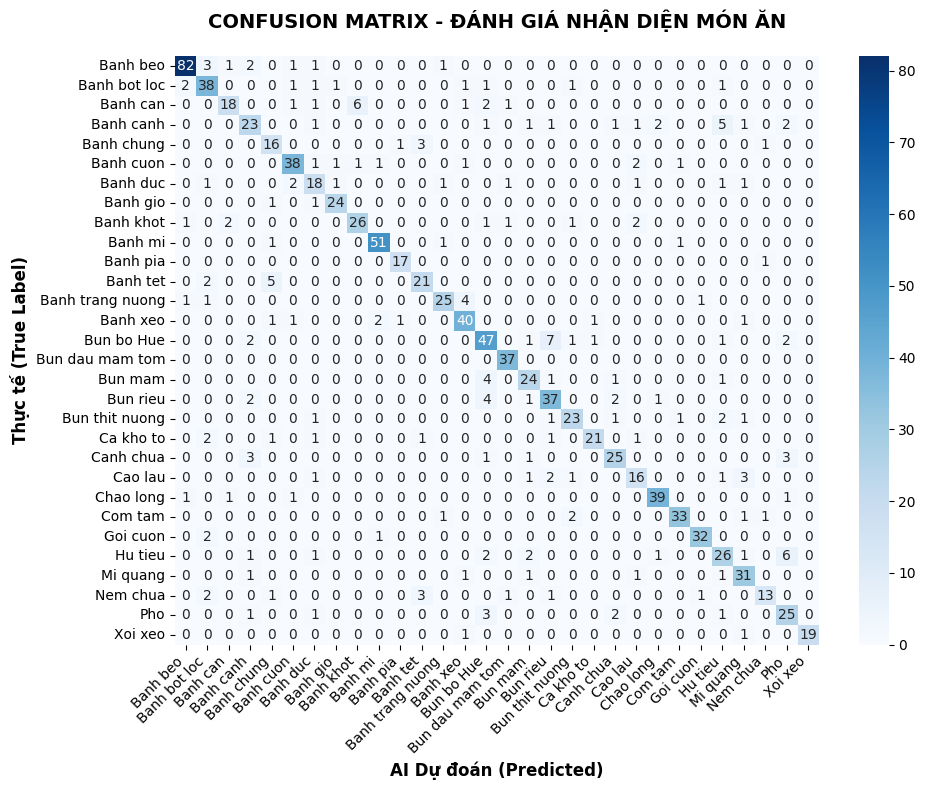

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from ultralytics import YOLO

# 1. Tải lại mô hình tốt nhất
best_model_path = '/content/runs/classify/vietfood_model/weights/best.pt' # Fixed path
model = YOLO(best_model_path)

val_dir = '/content/yolo_dataset/val'
# Sắp xếp tên class theo bảng chữ cái (Đúng với cách YOLO gán ID)
classes = sorted(os.listdir(val_dir))

y_true = []
y_pred = []

print(f"⏳ Đang dự đoán trên tập Validation để tính toán chỉ số (Có thể mất vài phút)...")

# 2. Quét toàn bộ ảnh trong tập Validation để dự đoán
for class_idx, class_name in enumerate(classes):
    class_path = os.path.join(val_dir, class_name)
    # Lấy các file ảnh hợp lệ
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for img_name in images:
        img_path = os.path.join(class_path, img_name)

        # Dự đoán (tắt verbose để không bị in ra quá nhiều log rác)
        results = model(img_path, verbose=False)

        # Lấy ID của class mà AI cho là có xác suất cao nhất
        pred_class_id = results[0].probs.top1

        # Lưu lại kết quả Thực tế vs Dự đoán
        y_true.append(class_idx)
        y_pred.append(pred_class_id)

# 3. Tính toán các chỉ số
acc = accuracy_score(y_true, y_pred)
# F1-score dùng 'weighted' để tính trung bình có xét đến số lượng ảnh của từng món
f1 = f1_score(y_true, y_pred, average='weighted')

print("\n" + "="*50)
print(f"🎯 KẾT QUẢ ĐÁNH GIÁ TỔNG QUAN:")
print(f"✔️ Accuracy (Độ chính xác tổng thể)  : {acc * 100:.2f}%")
print(f"✔️ F1-Score (Độ bao phủ & Chính xác) : {f1 * 100:.2f}%")
print("="*50 + "\n")

print("📋 BẢNG BÁO CÁO CHI TIẾT TỪNG MÓN (Classification Report):")
print(classification_report(y_true, y_pred, target_names=classes))

# 4. Vẽ biểu đồ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
# Vẽ heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)

plt.xlabel('AI Dự đoán (Predicted)', fontsize=12, fontweight='bold')
plt.ylabel('Thực tế (True Label)', fontsize=12, fontweight='bold')
plt.title('CONFUSION MATRIX - ĐÁNH GIÁ NHẬN DIỆN MÓN ĂN', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from google.colab import files

# Install ultralytics if it's not found
!pip install ultralytics
from ultralytics import YOLO

# 1. Trỏ tới file model tốt nhất của bạn
# (Mình lấy đường dẫn vietfood_model-6 theo log mới nhất bạn vừa chạy)
best_model_path = '/content/runs/classify/vietfood_model/weights/best.pt' # Fixed path
model_eval = YOLO(best_model_path)

print("📌 Vui lòng bấm 'Choose Files' để chọn 1 tấm ảnh từ máy tính...")
# 2. Bảng chọn file sẽ hiện ra
uploaded = files.upload()

if uploaded:
    # Lấy tên tệp vừa tải lên
    img_filename = list(uploaded.keys())[0]
    img_path = f'/content/{img_filename}'

    # 3. AI bắt đầu dự đoán (tắt verbose để log đỡ rối)
    results = model_eval(img_path, verbose=False)

    # 4. Hiển thị hình ảnh
    img = mpimg.imread(img_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')

    # 5. Phân tích kết quả
    for result in results:
        top5_classes = result.probs.top5
        top5_conf = result.probs.top5conf

        # Lấy món có điểm cao nhất in to lên đầu ảnh
        best_class = result.names[top5_classes[0]]
        best_conf = top5_conf[0].item() * 100
        plt.title(f"AI Dự Đoán: {best_class} ({best_conf:.2f}%)", fontsize=16, fontweight='bold', color='darkred')
        plt.show()

        # In bảng Top 5 ở dưới
        print("\n🔍 CHI TIẾT XÁC SUẤT (TOP 5):")
        print("-" * 35)
        for i in range(len(top5_classes)):
            class_id = top5_classes[i]
            class_name = result.names[class_id]
            confidence = top5_conf[i].item() * 100
            print(f"{i+1}. {class_name:<18}: {confidence:>6.2f}%")

    # Xóa ảnh tạm sau khi xem xong để Colab không bị đầy rác
    os.remove(img_path)
else:
    print("❌ Bạn chưa tải tấm ảnh nào lên!")

📌 Vui lòng bấm 'Choose Files' để chọn 1 tấm ảnh từ máy tính...


In [ ]:
!pip install ultralytics
from ultralytics import YOLO
from google.colab import files

best_model_path = '/content/runs/classify/vietfood_model/weights/best.pt'
model_export = YOLO(best_model_path)

print("⏳ Đang chuyển đổi sang định dạng TensorFlow.js...")
# Export file sang định dạng TensorFlow.js
exported_path = model_export.export(format='tfjs')

print(f"✅ Đã xuất file thành công tại: {exported_path}")

print("⬇️ Đang tải file tfjs về máy tính...")
# For tfjs, the output is a directory, not a single file.
# We need to zip the directory before downloading.
import shutil
output_zip_path = f"{exported_path}.zip"
shutil.make_archive(exported_path, 'zip', exported_path)
files.download(output_zip_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/classify/vietfood_model/weights/best.pt'